In [1]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# Modeling
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from itertools import product

In [3]:
# Import CSV and convert to pandas dataframe
data_path = "/Users/toripalecek/Documents/metafer_usage/metafer_usage/cleaned_data/cleaned_metafer_usage.csv"
data = pd.read_csv(data_path)
df = pd.DataFrame(data)
df.head()

,case_number,capture_date,scans,metafer,date,time,time_bin,month,weekday,weekday_index
0,26-684_MDSDF,2026-01-02 15:17:00,6,meta 2,2026-01-02,15:17:00,15:00:00,1,Friday,4
1,26-697_AMLFA,2026-01-02 13:47:00,10,meta 2,2026-01-02,13:47:00,13:30:00,1,Friday,4
2,26-698_AMLFA,2026-01-02 13:52:00,10,meta 7,2026-01-02,13:52:00,13:30:00,1,Friday,4
3,26-1081_EOSMF,2026-01-03 13:45:00,1,meta 1,2026-01-03,13:45:00,13:30:00,1,Saturday,5
4,26-1884_AMLFA,2026-01-02 13:51:00,4,meta 3,2026-01-02,13:51:00,13:30:00,1,Friday,4


In [ ]:
# Convert time_bin to datetime and calculate operational minutes since shifts cross midnight (3:00 AM)
#time = pd.to_datetime(df['time_bin'])

#df['operational_minutes'] = (
#    time.dt.hour * 60 + time.dt.minute - 180
#) % (24*60)
#df.head()

/var/folders/rr/bmtx3y515yq966zhdj0_1rhw0000gn/T/ipykernel_26209/91763925.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  time = pd.to_datetime(df['time_bin'])


,case_number,capture_date,scans,metafer,date,time,time_bin,month,weekday,weekday_index,operational_minutes
0,26-684_MDSDF,2026-01-02 15:17:00,6,meta 2,2026-01-02,15:17:00,15:00:00,1,Friday,4,720
1,26-697_AMLFA,2026-01-02 13:47:00,10,meta 2,2026-01-02,13:47:00,13:30:00,1,Friday,4,630
2,26-698_AMLFA,2026-01-02 13:52:00,10,meta 7,2026-01-02,13:52:00,13:30:00,1,Friday,4,630
3,26-1081_EOSMF,2026-01-03 13:45:00,1,meta 1,2026-01-03,13:45:00,13:30:00,1,Saturday,5,630
4,26-1884_AMLFA,2026-01-02 13:51:00,4,meta 3,2026-01-02,13:51:00,13:30:00,1,Friday,4,630


In [4]:
# Create a custom sklearn transformer for the time column. Convert into minutes with consideration for when shift changes are.
class TimeToOperationalMinutes(BaseEstimator, TransformerMixin):
    def __init__(self, start_hour=3):
        self.start_hour = start_hour

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        time = pd.to_datetime(X.iloc[:, 0])

        operational_minutes = (
            time.dt.hour * 60 
            + time.dt.minute 
            - self.start_hour * 60
        ) % (24 * 60)

        return operational_minutes.to_numpy().reshape(-1, 1)

In [12]:
# Drop unnecessary columns for clustering
drop_cols = ['case_number','capture_date','time','month','weekday_index','date','metafer']
df_drop = df.drop(drop_cols, axis=1)
df_drop.head()

,scans,time_bin,weekday
0,6,15:00:00,Friday
1,10,13:30:00,Friday
2,10,13:30:00,Friday
3,1,13:30:00,Saturday
4,4,13:30:00,Friday


In [13]:
df_drop.shape

(6571, 3)

In [14]:
# Create a column transformer to preprocess the data for clustering
num_features = ['scans']
cat_features = ['weekday']
time_feature = ['time_bin']

numberic_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

time_transformer = Pipeline(
    steps=[
        ("convert_time", TimeToOperationalMinutes()),
        ("scale_time", StandardScaler())
    ]
)
preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("Time", time_transformer, time_feature),
        ("StandardScaler", numberic_transformer, num_features)])

In [15]:
X = preprocessor.fit_transform(df_drop)

/var/folders/rr/bmtx3y515yq966zhdj0_1rhw0000gn/T/ipykernel_40481/2078213797.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  time = pd.to_datetime(X.iloc[:, 0])


In [27]:
# Check the shape of the transformed dataframe
X.shape

(6571, 9)

In [38]:
class DBSCANTuner:
    def __init__(self,
                 eps=(0.2, 0.4, 0.6, 0.8, 1.0),
                 min_samples=(4, 10, 20, 40, 80, 120),
                 noise_weight=1.0):

        self.eps = eps
        self.min_samples = min_samples
        self.noise_weight = noise_weight

    def fit(self, X):

        best_score = -np.inf
        best_params = None
        best_model = None
        results = []

        for eps, min_samples in product(self.eps, self.min_samples):

            model = DBSCAN(eps=eps, min_samples=min_samples)
            labels = model.fit_predict(X)

            mask = labels != -1

            # Need at least 2 clusters after removing noise
            if np.sum(mask) > 1 and len(np.unique(labels[mask])) > 1:

                silhouette = silhouette_score(X[mask], labels[mask])

                noise_fraction = np.mean(labels == -1)

                score = silhouette - self.noise_weight * noise_fraction
                results.append({
                        "eps": eps,
                        "min_samples": min_samples,
                        "silhouette": silhouette,
                        "noise_fraction": noise_fraction,
                        "score": score,
                        "clusters": len(np.unique(labels[mask]))})

                if score > best_score:
                    best_score = score
                    best_params = {
                        "eps": eps,
                        "min_samples": min_samples
                    }
                    best_model = model
                

        self.best_score_ = best_score
        self.best_params_ = best_params
        self.best_model_ = best_model
        self.results_ = pd.DataFrame(results).sort_values(by="score", ascending=False).reset_index(drop=True)

In [50]:
dbscan_tuner = DBSCANTuner()
dbscan_tuner.fit(X)

print("Best Score:", dbscan_tuner.best_score_)
print("Best Parameters:", dbscan_tuner.best_params_)
print("Results DataFrame:")
print(dbscan_tuner.results_)

Best Score: 0.34254142394259984
Best Parameters: {'eps': 0.4, 'min_samples': 80}
Results DataFrame:
    eps  min_samples  silhouette  noise_fraction     score  clusters
0   0.4           80    0.597906        0.255364  0.342541        16
1   0.2           10    0.389478        0.139096  0.250382       108
2   0.2           20    0.538317        0.288693  0.249625        56
3   0.4           40    0.331416        0.082940  0.248475        19
4   0.2           40    0.695548        0.460660  0.234887        34
5   0.4          120    0.659060        0.450160  0.208901        10
6   0.8           10    0.209151        0.000913  0.208238         7
7   0.8           20    0.209151        0.000913  0.208238         7
8   0.8            4    0.208959        0.000761  0.208199         7
9   1.0           10    0.208737        0.000609  0.208128         7
10  1.0           20    0.208737        0.000609  0.208128         7
11  1.0            4    0.208737        0.000609  0.208128         7
12 

In [52]:
df["cluster"] = dbscan_tuner.best_model_.labels_
df.head()

,case_number,capture_date,scans,metafer,date,time,time_bin,month,weekday,weekday_index,cluster
0,26-684_MDSDF,2026-01-02 15:17:00,6,meta 2,2026-01-02,15:17:00,15:00:00,1,Friday,4,0
1,26-697_AMLFA,2026-01-02 13:47:00,10,meta 2,2026-01-02,13:47:00,13:30:00,1,Friday,4,-1
2,26-698_AMLFA,2026-01-02 13:52:00,10,meta 7,2026-01-02,13:52:00,13:30:00,1,Friday,4,-1
3,26-1081_EOSMF,2026-01-03 13:45:00,1,meta 1,2026-01-03,13:45:00,13:30:00,1,Saturday,5,1
4,26-1884_AMLFA,2026-01-02 13:51:00,4,meta 3,2026-01-02,13:51:00,13:30:00,1,Friday,4,0


In [62]:
# View the average scans per cluster, weekday, and time_bin
summary = (df.groupby(["cluster","weekday","time_bin"]).agg(avg_scans=('scans', 'mean')))
summary.head()

avg_scans
cluster weekday time_bin           
-1      Friday  00:00:00   9.035714
                00:30:00   8.755556
                01:00:00   8.030303
                01:30:00   7.583333
                02:00:00   8.400000

In [70]:
# View the time range for each cluster by weekday
cluster_ranges = (
    df[df["cluster"] != -1]
      .groupby(["cluster", "weekday"])
      .agg(
          start_time=("time_bin", "min"),
          end_time=("time_bin", "max"),
          avg_scans=("scans", "mean"),
          observations=("scans", "count")
      )
      .reset_index()
)
cluster_ranges = cluster_ranges.round({"avg_scans": 2})

print(cluster_ranges)

    cluster    weekday start_time  end_time  avg_scans  observations
0         0     Friday   04:30:00  19:30:00       4.77           466
1         1   Saturday   07:00:00  20:00:00       4.63          1064
2         2   Saturday   08:00:00  15:00:00      12.19           206
3         3     Monday   04:30:00  12:00:00       5.57           176
4         4    Tuesday   07:00:00  13:00:00       5.76           122
5         5  Wednesday   00:00:00  23:30:00       5.58           308
6         6     Friday   00:00:00  23:00:00       5.32           346
7         7  Wednesday   05:30:00  18:30:00       4.44           355
8         8   Thursday   00:00:00  23:30:00       5.36           371
9         9   Thursday   04:30:00  19:00:00       4.68           502
10       10     Monday   00:00:00  23:30:00       5.78           130
11       11     Sunday   15:00:00  23:30:00       5.45           390
12       12    Tuesday   00:00:00  23:30:00       5.67           191
13       13     Friday   07:00:00 

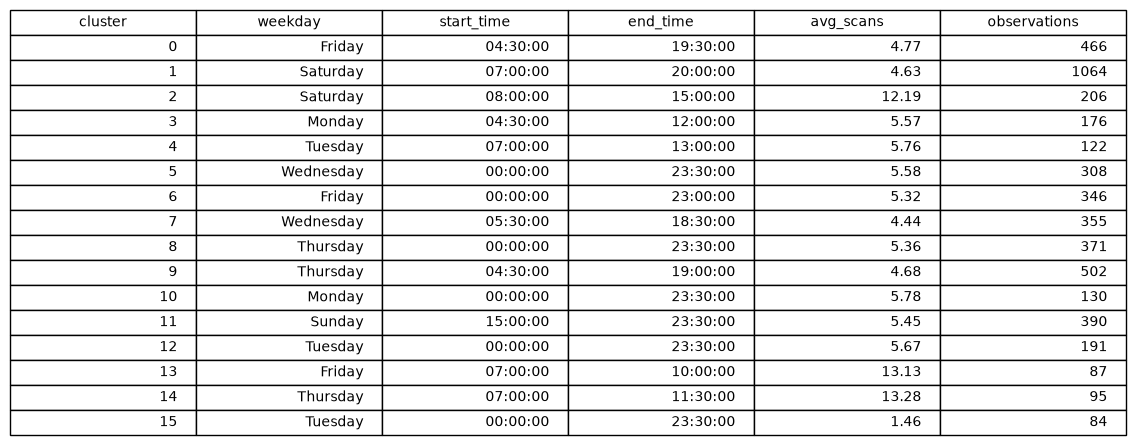

In [71]:
# Create a table of the cluster ranges and save it as an image
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

cluster_table = ax.table(
    cellText=cluster_ranges.values,
    colLabels=cluster_ranges.columns,
    loc="center"
)

cluster_table.auto_set_font_size(False)
cluster_table.set_fontsize(10)
cluster_table.scale(1.2, 1.5)

plt.show()

In [63]:
# Create a table for the official active scanner windows for each weekday

scanner_windows = pd.DataFrame({
    "Weekday": [
        "Sunday",
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday"
    ],
    "Start Time": [
        "15:00",
        "11:30",
        "N/A",
        "5:30",
        "4:30",
        "4:30",
        "7:00"
    ],
    "End Time": [
        "23:30",
        "19:30",
        "N/A",
        "11:30",
        "11:30",
        "10:00",
        "10:00"
    ]
})

print(scanner_windows)

     Weekday Start Time End Time
0     Sunday      15:00    23:30
1     Monday      11:30    19:30
2    Tuesday        N/A      N/A
3  Wednesday       5:30    11:30
4   Thursday       4:30    11:30
5     Friday       4:30    10:00
6   Saturday       7:00    10:00


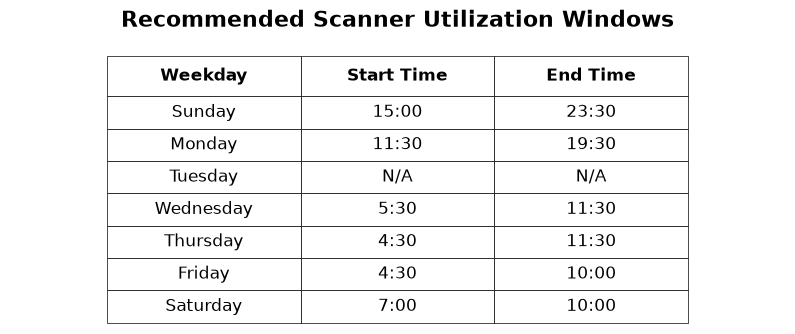

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axis("off")

table = ax.table(
    cellText=scanner_windows.values,
    colLabels=scanner_windows.columns,
    loc="center",
    cellLoc="center",
    colLoc="center"
)

# Font and sizing
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.3, 1.8)

# Adjust individual cells
for (row, col), cell in table.get_celld().items():
    cell.set_linewidth(0.5)
    
    # Header row
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_height(0.15)
    else:
        cell.set_height(0.12)

# Adjust column widths
for col in range(len(scanner_windows.columns)):
    for row in range(len(scanner_windows) + 1):
        table[row, col].set_width(0.25)

# Add title
plt.title(
    "Recommended Scanner Utilization Windows",
    fontsize=16,
    weight="bold",
    pad=20
)

plt.show()